## Script to generate figure 1

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('.').resolve().parent))
import matplotlib.pyplot as plt
import module_ESN
import module_graph
import module_generate_data
from netgraph import Graph as plotGraph
from scipy.stats import beta, sem
import matplotlib.pyplot as plt
import numpy as np
import netgraph
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib 
from netgraph._edge_layout import *
from netgraph._node_layout import get_fruchterman_reingold_layout, _remove_node_overlap
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
## other option that does print double edges for when netgraph doesn't work
import numpy as np
import networkx as nx
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)
## function to compute all data for the step by step optimization and display 

def optimize_node(esn,  trials, proxy_nodes, is_goal=False):

    n = esn.n 
    num_action_nodes = len(esn.action_nodes)
    start_time = esn.proxy_discard*(not is_goal) + esn.goal_discard*is_goal
    end_time = start_time + esn.measure_time
    # define function to test an agent action 
    def test_agent_action(agent_action, action_value):
        """
        Test the average value of an action node if all other nodes are set to random values
        """
        proxy_samples    = np.asarray([])
        goal_samples    = np.asarray([])
        esn.reset_seed()
        for j in range(trials): 
            action_node_values = esn.get_directed_action_value(action_value , agent_action, actionsize = len(esn.action_nodes))
            states = esn.run(agent_values=action_node_values)
            proxy_samples = np.concatenate((proxy_samples,np.mean(states[start_time:end_time, proxy_nodes], axis=0)))
            goal_samples = np.concatenate((goal_samples,np.mean(states[esn.goal_discard:esn.goal_discard+esn.measure_time, esn.goal], axis=0)))
        if not is_goal:
            correl_node_goal = np.corrcoef(proxy_samples, goal_samples)[0, 1]
        else:
            correl_node_goal = 0

        return np.mean(proxy_samples), np.mean(goal_samples), correl_node_goal, proxy_samples, goal_samples
    max_proxy_value = -1
    goal_value_on_max_proxy = -1
    correlation_on_max_proxy = 0
    mean_proxy_list = []
    prox_samples = []
    _, _, _, proxy_base, goal_base = test_agent_action(0, 0)
    for i in range(num_action_nodes):
        for val in [-1, 1]:
            proxy_value, goal_value, correl_node_goal, proxy_samples, goal_samples = test_agent_action(i, val)
            mean_proxy_list.append(proxy_value) # for fig D 
            if proxy_value > max_proxy_value:
                max_proxy_value = proxy_value
                goal_value_on_max_proxy = goal_value
                correlation_on_max_proxy = correl_node_goal
                max_prox_samples = proxy_samples
                max_goal_samples = goal_samples
            prox_samples.append(proxy_samples)

    return (goal_value_on_max_proxy, max_proxy_value, correlation_on_max_proxy, mean_proxy_list, max_prox_samples, max_goal_samples, proxy_base, goal_base,prox_samples)

In [2]:
param_grid = {
    'n': [128], 
    'trials': [50],
    'proxy_discard': [50],
    'goal_discard': [250],
    'measure_time': [50],
    'spectral_radius': [1.25],
    'alpha': [0.1],
    "avg_number_of_edges": [1.25],
    "number_of_action_nodes": [16],
    "seed": [42]                          # note that picking the seed is only ok because the goal of this figure is to be illustrative.
}
goal_color = "tab:green"
proxy_color = "greenyellow"
positive_color = "tab:red"
negative_color = "tab:blue"
#style_name = #'ggplot' # 'seaborn-v0_8-dark'
#plt.style.use(style_name)


param_ESN = dict(zip(param_grid.keys(), [param_grid[k][0] for k in param_grid.keys()]))
esn = module_ESN.EchoStateNetwork(param_ESN['n'],  spectral_radius=param_ESN['spectral_radius'], alpha = param_ESN['alpha'], 
                            avg_number_of_edges=param_ESN['avg_number_of_edges'], proxy_discard=param_ESN['proxy_discard'],
                            goal_discard=param_ESN['goal_discard'], measure_time=param_ESN['measure_time'], 
                            seed=param_ESN['seed'],number_of_action_nodes=param_ESN['number_of_action_nodes'])
esn.reset_seed()
proxy_nodes, goal_value, proxy_value, correlations, bin_indices = module_generate_data.compute_proxy_nodes_from_esn(esn, param_ESN['trials'])


goal_value_on_max_proxy, max_proxy_value, correlation_on_max_proxy, mean_proxy_list, max_prox_samples, max_goal_samples, proxy_base, goal_base,prox_samples = optimize_node(esn,  40, proxy_nodes, is_goal=False)
print(max_goal_samples)



[5.25695725e-06 4.79639514e-06 7.55572559e-06 6.63928620e-06
 8.37306104e-06 5.80163662e-06 5.59991530e-06 9.92588005e-06
 7.24588032e-06 8.23184940e-06 8.26820148e-06 5.67923542e-06
 5.79740762e-06 6.37389535e-06 9.99773359e-06 5.80101990e-06
 5.84837909e-06 8.12648643e-06 6.77262848e-06 7.67466119e-06
 3.80626914e-06 7.65843639e-06 9.32319694e-06 6.52406442e-06
 1.00118107e-05 7.61309380e-06 9.61169812e-06 3.88044972e-06
 8.51946263e-06 4.29899672e-06 7.39512800e-06 7.73350526e-06
 5.03655905e-06 8.90281583e-06 6.87941101e-06 5.09177474e-06
 8.40842625e-06 7.21305040e-06 7.49789510e-06 6.49870717e-06]


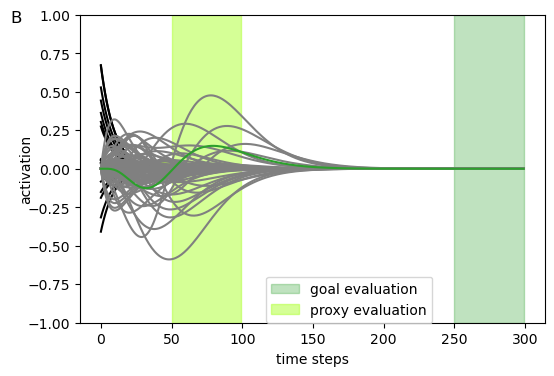

In [3]:


def plot_temporal(ax,ESN, proxy_node = None):
    G = module_graph.outputgraph(ESN.W)
    n = max(G.nodes())
    colors = { node:  goal_color*(node == n)+  'gray'*(ESN.number_of_action_nodes<=node and node<n) + 'k'*(node <ESN.number_of_action_nodes )   for node in G.nodes() }
    list_color = [ colors[i] if not proxy_node or i != proxy_node else proxy_color for i in range(n+1)]
    esn.reset_seed()
    actions = esn.get_base_action_value(len(ESN.action_nodes))
    states = ESN.run( agent_values=actions)
    for k in range(n+1):
        p = ax.plot(states[:, k], color = list_color[k])
    ax.set_title('B', loc='left', x= -0.15, y = 0.95)
    ax.set_xlabel('time steps')
    ax.set_ylabel('activation', labelpad=-4)
    ax.set_ylim(-1,1)
    
    g = ESN.goal_discard
    p =  ESN.proxy_discard
    m = ESN.measure_time
    ax.fill_between(range(g , g+m  ),-1, 1,  color = goal_color, alpha=0.3, label ="goal evaluation")
    ax.fill_between(range(p , p+m  ),-1, 1,  color = proxy_color, alpha=0.5, label ="proxy evaluation")
    ax.legend(loc =(0.4,0))
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_temporal(ax,esn, proxy_node=proxy_nodes[0])
plt.savefig("figures_output/fig2_B.svg", format="svg", bbox_inches="tight", transparent=True)

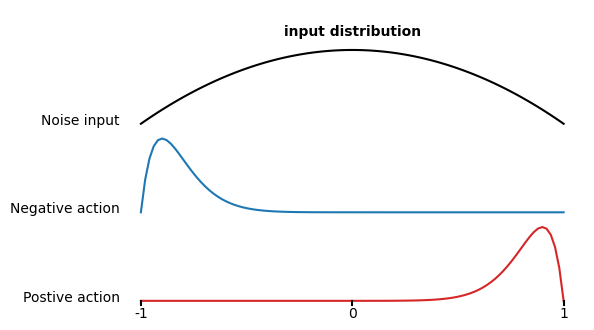

In [4]:
def plot_beta_distributions(ax, input_type = "noise"):
    a_list = [20,2,2]
    b_list = [2,20,2]
    l_list = ["Postive action","Negative action",'Noise input']
    c_list = [positive_color, negative_color, 'k']
    i = np.linspace(0, 1, 100)

    ax.yaxis.set_ticks([])
    ax.xaxis.set_ticks([])
    ax.spines[:].set_visible(False)
    for k in range(3):
        y = beta.pdf(i, a_list[k], b_list[k])
        Y = y/np.max(y) + k*1.2
        X = i * 2 - 1
        ax.plot(X, Y, color = c_list[k])

        ax.text(X[0]-0.1, Y[0], l_list[k],horizontalalignment='right')

    #ax.text(X[0]-0.1, (k+1)*1.2, "input option",horizontalalignment='right', fontweight='bold')
    ax.text(X[0]+1, (k+1)*1.2, "input distribution",horizontalalignment='center', fontweight='bold')

    for x in [-1, 0, 1]:
        ax.plot([x, x], [0, -0.05], color="black")

    # Add custom labels
    for x, label in zip([-1, 0, 1], ["-1", "0", "1"]):
        ax.text(x, -0.07, label, ha="center", va="top")

    
    
    

    lim = ax.get_ylim()
    ax.set_ylim(lim[0] ,lim[1]+ 0.1*(lim[1]- lim[0]))
    #ax.vlines(X[0]-0.05,lim[0],lim[1]+ 0.1*(lim[1]- lim[0]), linewidth = 1)
    limx = ax.get_xlim()
    #ax.hlines((k+1)*1.2-0.05,-2,limx[1], linewidth = 1)
    
    

    

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_beta_distributions(ax)

/tmp/ipykernel_3956/1859419177.py:26: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  edge_paths = get_curved_edge_paths(list(G.edges()), pos2, node_size=node_size)
/home/paulbanse/anaconda3/lib/python3.12/site-packages/netgraph/_main.py:911: RuntimeWarning: divide by zero encountered in scalar divide
  rescale_factor = min(rescale_factor, diameter/np.sqrt(width**2 + height**2))


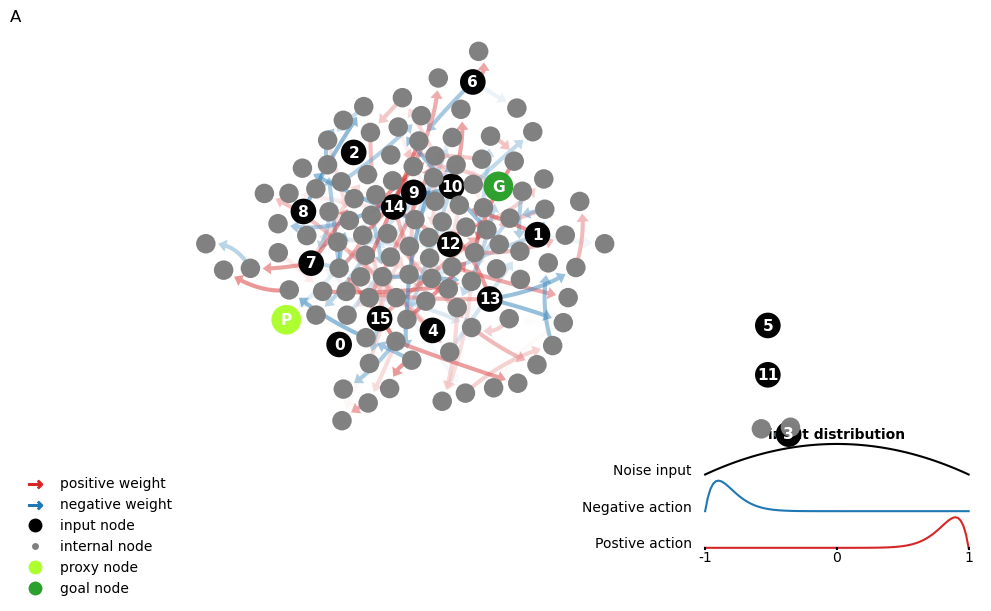

In [5]:

def plot_graph_cool_esn_2(ESN, ax11, prop, show_numbers = False, proxy_node = None):
    node_size = 5.0
    G = module_graph.outputgraph(ESN.W)
    cmap =matplotlib.colors.LinearSegmentedColormap.from_list("", [negative_color,"white", positive_color]) #'coolwarm'
    H = G.__class__()                     # keeps Graph vs DiGraph
    H.add_nodes_from(G.nodes(data=True))   # copy node attrs
    H.add_edges_from(
        (u, v, {k: val for k, val in d.items() if k != "weight"})
        for u, v, d in G.edges(data=True))
    n = max(G.nodes())


    fig_w, fig_h = ax11.figure.get_size_inches()
    ax_w =  (fig_w) *2/3
    ax_h =  (fig_h) *2/3
    scale = (ax_w,ax_h)
    np.random.seed(1)
    pos = get_fruchterman_reingold_layout(list(H.edges()) , scale = scale, origin=(0,0)) 
    z = 0
    for k in range(n):
        if k not in pos.keys():
            pos[k] = np.array([0, z*6])
            z += 1
    pos2 = pos #{k: np.array([a[0], a[1] + 0.2 * fig_h]) for k, a in pos.items()}

    edge_paths = get_curved_edge_paths(list(G.edges()), pos2, node_size=node_size)
    #for (a,b), path in edge_paths.items():
    #    if a< b and (b,a) in edge_paths:
    #       edge_paths[(b,a)] = path[::-1] 
    colors = { node:  goal_color*(node == n)+  'gray'*(ESN.number_of_action_nodes<=node and node<n) + 'k'*(node <ESN.number_of_action_nodes )   for node in G.nodes() }
    sizess = { node:  17*(node == n)+  12*(ESN.number_of_action_nodes<=node and node<n) + 15*(node <ESN.number_of_action_nodes )   for node in G.nodes() }
    if proxy_node :
        colors[proxy_node] = proxy_color
        sizess[proxy_node] = 17
    labs = {node: str(node)*int(node < ESN.number_of_action_nodes)+ 'G'*int(node == ESN.n-1) + "P"*int(node == proxy_node) for node in G.nodes() if show_numbers}
    plotGraph(G, ax = ax11,
              node_layout="spring",#pos2,
              edge_layout="curved", #edge_paths,
              node_size=sizess,
              edge_width=4.,
              node_edge_width=5,
              arrows=True,
              directed=True,
              edge_cmap=cmap,
              node_color=colors,
              node_edge_color= "none",
              node_labels=labs,
              node_label_fontdict= {"color":'white', 'weight':'bold'},
              node_label_offset=0,
              node_alpha=0.99 , scale = scale,
              edge_layout_kwargs=dict(bundle_parallel_edges=False, k=0.5))
    
    ax11.scatter([],[],marker=r'$\rightarrow$', label='positive weight', color=positive_color, s=100)
    ax11.scatter([],[],marker=r'$\rightarrow$', label='negative weight', color=negative_color, s=100)
    handles, labels = ax11.get_legend_handles_labels()
    node = Line2D([0], [0], label='internal node', marker='.', markersize=10, markeredgecolor= 'none', markerfacecolor='gray', linestyle='')
    input = Line2D([0], [0], label='input node', marker='.', markersize=20, markeredgecolor= 'none', markerfacecolor='k', linestyle='')
    goal = Line2D([0], [0], label='goal node', marker='.', markersize=20, markeredgecolor= 'none', markerfacecolor=goal_color, linestyle='')
    handles.extend([input,node])

    if  proxy_node :
        proxy = Line2D([0], [0], label='proxy node', marker='.', markersize=20, markeredgecolor= 'none', markerfacecolor=proxy_color, linestyle='')
        handles.extend([ proxy])
    handles.extend([goal])
    ax11.legend(handles=handles, ncol = 1, loc = (0,0),frameon = False)
    ax11.set_title('A', y = 1, x = 0, pad = 0)
    mult_for_space = 0.3
    limy,limx = ax11.get_ylim() ,ax11.get_xlim()
    spany, spanx = limy[1]- limy[0], limx[1]- limx[0]
    
    ax11.set_ylim(limy[0] - mult_for_space*(spany),limy[1])
    miss_x = (spany*(1+mult_for_space))*ax_w/ax_h- spanx 
    ax11.set_xlim(-miss_x/2 + limx[0],+miss_x/2 + limx[1] )


    limy,limx = ax11.get_ylim() ,ax11.get_xlim()
    spany, spanx = limy[1]- limy[0], limx[1]- limx[0]

    ax_histA = ax11.inset_axes([1-prop, 0.08, prop, mult_for_space-0.08])
    ax_histA.tick_params(direction='in')
    plot_beta_distributions(ax_histA)


fig = plt.figure(layout = "constrained", figsize =(10,6))
gs00 = gridspec.GridSpec(1, 1, figure=fig)
ax1 = fig.add_subplot(gs00[:,0])
plot_graph_cool_esn_2(esn, ax1,0.3, show_numbers=True, proxy_node=proxy_nodes[0])

plt.savefig("figures_output/fig2_A.svg", format="svg", bbox_inches="tight", transparent=True)

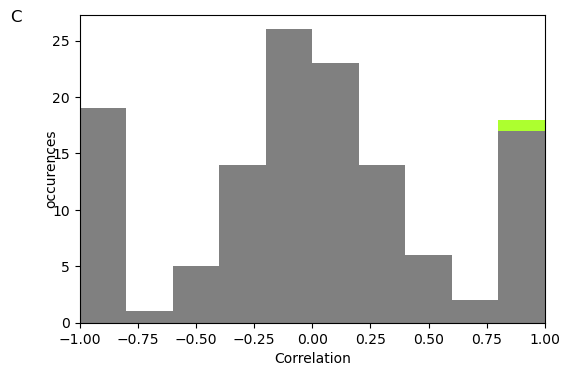

In [6]:
def plot_correlations(correlations,ax):
    L = sorted(correlations)
    bins = 10
    ax.hist([L[:-1], L[-1:]], color =['gray',proxy_color], stacked = True, bins = [2*k/bins-1 for k in range(bins+1)])
    ax.set_xlim(-1, 1)
    ax.set_title('C', loc='left', x= -0.15, y = 0.95)
    ax.set_xlabel('Correlation')
    ax.set_ylabel('occurences', labelpad=-4)


fig, ax = plt.subplots(1, 1, figsize=(6, 4))

plot_correlations(correlations,ax)
plt.savefig("figures_output/fig2_C.svg", format="svg", bbox_inches="tight", transparent=True)

In [7]:
prox_samples[0][0]

0.015200757297478343

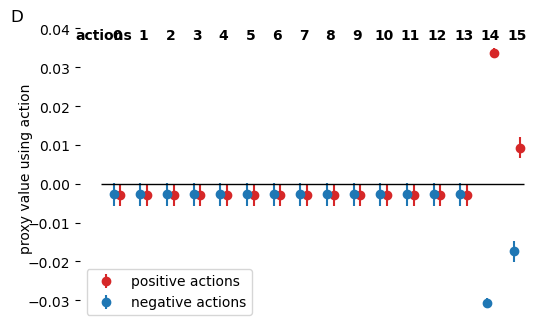

In [8]:
def histogram_goodactions(ax, L):
    nAction = len(L)//2
    Xplus = [k+0.125 for k in range(nAction)]
    X = [k for k in range(nAction)]
    Xmoins = [k-0.125 for k in range(nAction)]
    negative_actions = L[::2]
    positive_actions =  L[1::2]
    mean_pos = [np.mean(x) for x in positive_actions]
    mean_neg = [np.mean(x) for x in negative_actions]
    sem_pos = [sem(x) for x in positive_actions]
    sem_neg = [sem(x) for x in negative_actions]
    text_height = 1.1*np.max(mean_pos + mean_neg)+ np.max(sem_pos + sem_neg)
    ax.errorbar(Xplus, mean_pos,yerr = sem_pos, fmt='o',color =positive_color, label="positive actions")
    ax.errorbar(Xmoins, mean_neg,yerr = sem_neg, fmt='o',color =negative_color, label="negative actions")
    ax.set_ylabel('proxy value using action', labelpad=-4)
    #ax.yaxis.set_ticks([])
    ax.xaxis.set_ticks([])
    ax.spines[:].set_visible(False)
    #for x in X:
    #    ax.plot([x, x], [0, -0.005], color="black")
    ax.hlines(0,-0.6,nAction-1+0.25,'k', linewidth = 1) 
    # Add custom labels
    ax.text(-0.5, text_height, 'actions', ha="center", va="top", fontweight = 'bold')
    ax.plot(-0.6,text_height)
    for x in X:
        ax.text(x, text_height, str(x), ha="center", va="top", fontweight = 'bold')
    ax.legend()
    
    ax.set_title('D', loc='left', x= -0.15, y = 0.95)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
histogram_goodactions(ax, prox_samples)
plt.savefig("figures_output/fig2_D.svg", format="svg", bbox_inches="tight", transparent=True)


[5.25695725e-06 4.79639514e-06 7.55572559e-06 6.63928620e-06
 8.37306104e-06 5.80163662e-06 5.59991530e-06 9.92588005e-06
 7.24588032e-06 8.23184940e-06 8.26820148e-06 5.67923542e-06
 5.79740762e-06 6.37389535e-06 9.99773359e-06 5.80101990e-06
 5.84837909e-06 8.12648643e-06 6.77262848e-06 7.67466119e-06
 3.80626914e-06 7.65843639e-06 9.32319694e-06 6.52406442e-06
 1.00118107e-05 7.61309380e-06 9.61169812e-06 3.88044972e-06
 8.51946263e-06 4.29899672e-06 7.39512800e-06 7.73350526e-06
 5.03655905e-06 8.90281583e-06 6.87941101e-06 5.09177474e-06
 8.40842625e-06 7.21305040e-06 7.49789510e-06 6.49870717e-06]


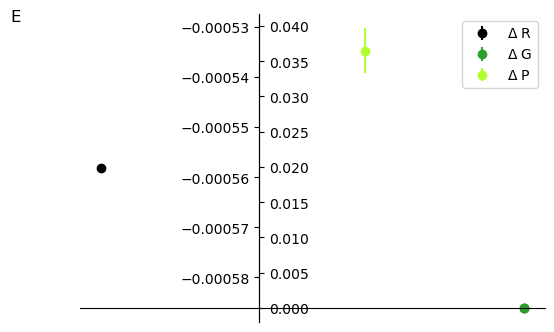

In [9]:

def plot_all_diffs(ax,max_goal_samples, max_prox_samples,proxy_base, goal_base, correlations, correlation_on_max_proxy):
    print(max_goal_samples)
    k = len(max_goal_samples)
    diff_corr = correlation_on_max_proxy - np.max(correlations) 
    diff_goal = np.mean(max_goal_samples) - np.mean(goal_base) 
    diff_proxy = np.mean(max_prox_samples) - np.mean(proxy_base) 
    goal_err = (np.std(max_goal_samples)**2/k + np.std(goal_base)**2/k )**0.5
    proxy_err = (np.std(max_prox_samples)**2/k + np.std(proxy_base)**2/k )**0.5
    ax.errorbar(-0.6, diff_corr,yerr = 0, fmt='o',color ="k")
    #ax.arrow(-0.5,0,0,diff_corr*0.8, width = 0.05, color = "k", head_length=np.abs(diff_corr*0.2))
    ax2 = ax.twinx()
    #ax2.arrow(1,0,0,diff_proxy*0.8, width = 0.05,color = proxy_color, head_length=np.abs(diff_proxy*0.2))
    #ax2.arrow(2,0,0,diff_goal*0.8, width = 0.05, color = goal_color, head_length=np.abs(diff_goal*0.2))
    ax2.errorbar(1,diff_goal ,yerr =0  , fmt='o',color ="k", label=r'$\Delta$ R')
    ax2.errorbar(1,diff_goal ,yerr =goal_err  , fmt='o',color =goal_color, label=r'$\Delta$ G')
    ax2.errorbar(0.4,diff_proxy ,yerr = proxy_err, fmt='o',color =proxy_color, label=r'$\Delta$ P')
    
    ax.spines['left'].set_position(('data', 0.0))
    ax.spines['bottom'].set_position(('data', 0.0))
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax2.spines['right'].set_position(('data', 0.0))
    ax2.spines['bottom'].set_position(('data', 0.0))
    ax2.spines['left'].set_color('none')
    ax2.spines['top'].set_color('none')
    ax2.plot([0],[0])
    ax.set_xticks([])
    ax.set_title('E', loc='left', x= -0.15, y = 0.95)
    ax2.legend()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_all_diffs(ax,max_goal_samples, max_prox_samples,proxy_base, goal_base, correlations, correlation_on_max_proxy)
plt.savefig("figures_output/fig2_E.svg", format="svg", bbox_inches="tight", transparent=True)

-0.0005581870372092235


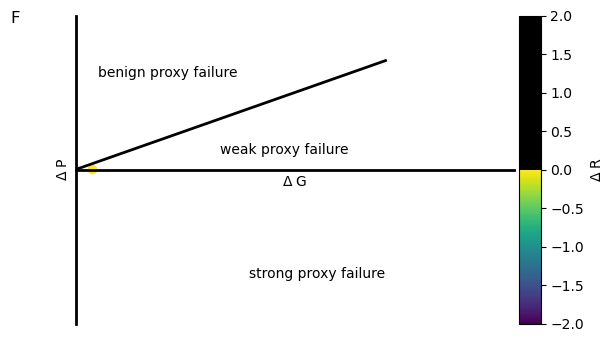

In [10]:

def figure_quadrants(ax, goal_value_on_max_proxy, max_proxy_value,proxy_base, goal_base, corrlist, optimized_corr):
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    s = 2**0.5/2
    
    ax.text(0.05,0.6,"benign proxy failure")
    ax.text(0.33,0.1,"weak proxy failure")
    ax.text(s,-s,"strong proxy failure", horizontalalignment = "right")
    ax.set_ylabel(r'$\Delta$ P')
    ax.set_xlabel(r'$\Delta$ G')

    vir = matplotlib.colormaps["viridis"]     # first half
    red = np.tile([0, 0, 0, 1], (128, 1))      # second half = solid red (RGBA)

    colors = np.vstack((vir(np.linspace(0, 1, 128)), red))
    half_viridis_half_red = LinearSegmentedColormap.from_list(
        "half_viridis_half_red", colors
    )
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    temp = ax.scatter( max_proxy_value- np.mean(proxy_base), goal_value_on_max_proxy - np.mean(goal_base) ,c = [optimized_corr - max(corrlist)], label = "current situation",  cmap=half_viridis_half_red, vmin = -2, vmax = 2)
    
    
    cbar = ax.figure.colorbar(temp, cax=cax, orientation='vertical')
    cbar.set_label(r'$\Delta$ R')
    print(optimized_corr - max(corrlist))
    ax.plot([0,s],[0,s], "k", linewidth = 2)
    ax.plot([0,-s],[0,-s], "k", linewidth = 1)
    ax.set_title('F', loc='left', x= -0.15, y = 0.95)
    ax.spines['left'].set_position(('data', 0.0))
    ax.spines['bottom'].set_position(('data', 0.0))
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(-1,1)
    ax.set_xlim(0,1)



fig, ax = plt.subplots(1, 1, figsize=(6, 4))
figure_quadrants(ax, goal_value_on_max_proxy, max_proxy_value,proxy_base, goal_base, correlations, correlation_on_max_proxy)

#plt.savefig("figures_output/fig2_F.svg", format="svg", bbox_inches="tight", transparent=True)

## Full figure now

/tmp/ipykernel_3956/1859419177.py:26: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  edge_paths = get_curved_edge_paths(list(G.edges()), pos2, node_size=node_size)
/home/paulbanse/anaconda3/lib/python3.12/site-packages/netgraph/_main.py:911: RuntimeWarning: divide by zero encountered in scalar divide
  rescale_factor = min(rescale_factor, diameter/np.sqrt(width**2 + height**2))


[5.25695725e-06 4.79639514e-06 7.55572559e-06 6.63928620e-06
 8.37306104e-06 5.80163662e-06 5.59991530e-06 9.92588005e-06
 7.24588032e-06 8.23184940e-06 8.26820148e-06 5.67923542e-06
 5.79740762e-06 6.37389535e-06 9.99773359e-06 5.80101990e-06
 5.84837909e-06 8.12648643e-06 6.77262848e-06 7.67466119e-06
 3.80626914e-06 7.65843639e-06 9.32319694e-06 6.52406442e-06
 1.00118107e-05 7.61309380e-06 9.61169812e-06 3.88044972e-06
 8.51946263e-06 4.29899672e-06 7.39512800e-06 7.73350526e-06
 5.03655905e-06 8.90281583e-06 6.87941101e-06 5.09177474e-06
 8.40842625e-06 7.21305040e-06 7.49789510e-06 6.49870717e-06]
-0.0005581870372092235


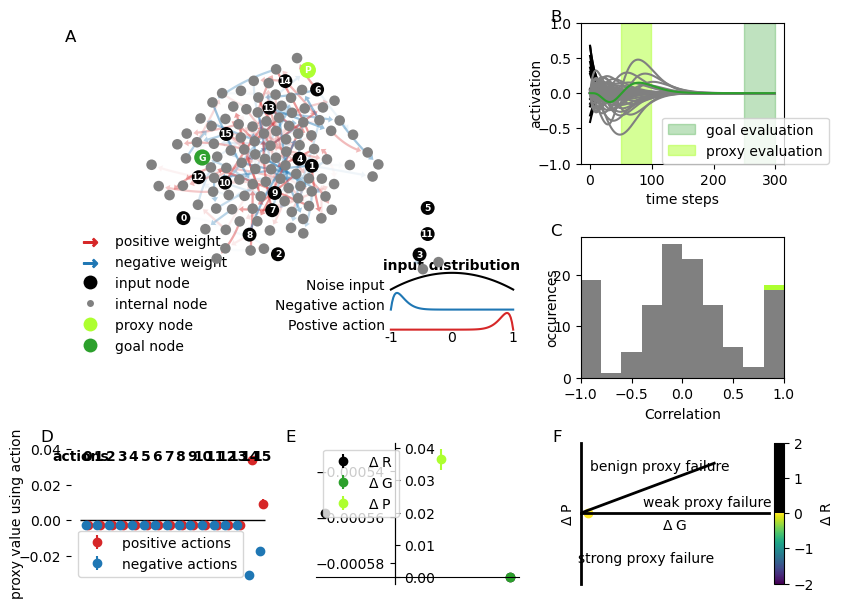

In [11]:





fig = plt.figure(layout = "constrained", figsize =(8.27,11.69/2))
gs = fig.add_gridspec(2, 2, left=0.1, right=0.95, top=0.95, bottom=0.1, wspace=0.3, hspace=0.3)

gs = gridspec.GridSpec(3, 3, figure=fig)

ax11 = fig.add_subplot(gs[:2,:2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 2])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2:,1])
ax6 = fig.add_subplot(gs[2, 2])



#fig, ((ax1,ax2,ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, )
plot_graph_cool_esn_2(esn, ax11, 0.3,proxy_node=proxy_nodes[0], show_numbers=True)
#plot_beta_distributions(ax2)
plot_temporal(ax2,esn)
plot_correlations(correlations,ax3)
histogram_goodactions(ax4, prox_samples)
plot_all_diffs(ax5,max_goal_samples, max_prox_samples,proxy_base, goal_base, correlations, correlation_on_max_proxy)
figure_quadrants(ax6, goal_value_on_max_proxy, max_proxy_value,proxy_base, goal_base, correlations, correlation_on_max_proxy)
#plot_graph_cool_esn_2(esn, ax5,proxy_node=proxy_nodes[0] )
#plot_beta_distributions(ax5,False)
plt.savefig("figures_output/fig2.svg", format="svg", bbox_inches="tight", transparent=True)


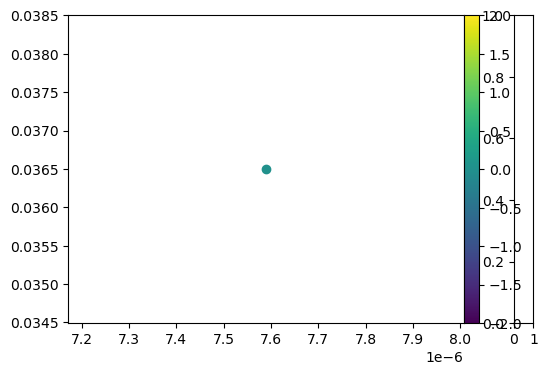

In [12]:

data = np.arange(100, 0, -1).reshape(10, 10)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.5)
temp = ax.scatter(goal_value_on_max_proxy - np.mean(goal_base) , max_proxy_value- np.mean(proxy_base), c = 0, label = "current situation",  cmap='viridis', vmin = -2, vmax = 2)


cbar = fig.colorbar(temp, ax=cax, orientation='vertical')
plt.show()

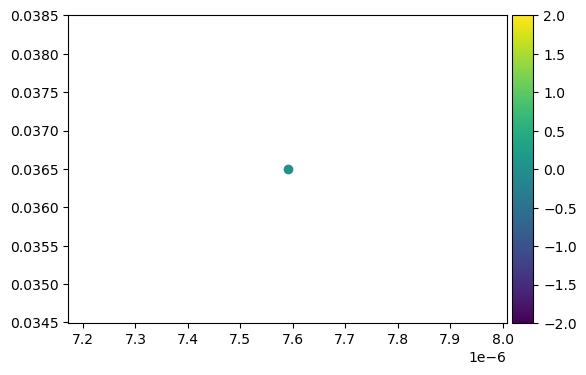

In [13]:
data = np.arange(100, 0, -1).reshape(10, 10)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

temp = ax.scatter(goal_value_on_max_proxy - np.mean(goal_base) , max_proxy_value- np.mean(proxy_base), c = 0, label = "current situation",  cmap="viridis", vmin = -2, vmax = 2)

cbar = fig.colorbar(temp, cax=cax, orientation='vertical')
plt.show()